# Reviewer Feedback Analysis Notebook

Notebook ini dibuat untuk menghasilkan data real yang menjawab feedback reviewer tanpa membuat data sintetis. Semua input dibaca dari repository ini: dataset original, dataset Roboflow, label segmentasi, model/CSV hasil eksperimen, dan notebook lama hanya dipakai sebagai referensi path.

Output akan ditulis ke `reviewer_feedback_outputs/`.

In [1]:
from pathlib import Path
import os
import re
import math
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import cv2
except Exception as exc:
    raise ImportError("Notebook ini membutuhkan opencv-python sesuai requirements.txt") from exc

try:
    from scipy import stats
except Exception as exc:
    raise ImportError("Notebook ini membutuhkan scipy sesuai requirements.txt") from exc

ROOT = Path.cwd()
OUT = ROOT / "reviewer_feedback_outputs"
OUT.mkdir(exist_ok=True)

ORIGINAL_DIR = ROOT / "dataset_collection/original/original_dataset"
MAPPING_CSV = ORIGINAL_DIR / "mapping.csv"
MAPPING_SUBSET_CSV = ORIGINAL_DIR / "mapping_subset.csv"
TRAIN_CSV = ORIGINAL_DIR / "train.csv"
ORIGINAL_IMAGE_DIR = ORIGINAL_DIR / "train_images"

SEG_DATASET = ROOT / "dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession"
OD_DATASET_10K = ROOT / "dataset_collection/roboflow/object_detection/object_detection_all_class_10k_images"

SEVERITY_RESULT_DIR = ROOT / "severity_estimation_experiment/results"
GT_RESULT_DIR = ROOT / "ground_truth_experiment/results"
OD_MODEL_PATH = ROOT / "severity_estimation_experiment/best_model/object_detection/best.pt"

LEAF_CLASSES = {0, 2, 3}
LESION_CLASSES = {1, 4}
CLASS_NAMES = {
    0: "frog-eye-leaf-spot",
    1: "frog-eye-leaf-spot_lession",
    2: "healthy",
    3: "rust",
    4: "rust_lession",
}
TARGET_CLASSES = ["frog_eye_leaf_spot", "healthy", "rust"]

RUN_OPTIONAL_DETECTION_AUDIT = True
RANDOM_SEED = 42
BOOTSTRAP_N = 10000

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
print(f"Repository root: {ROOT}")
print(f"Output dir: {OUT}")

Repository root: c:\Users\abiyamf\Documents\Code Program\Thesis
Output dir: c:\Users\abiyamf\Documents\Code Program\Thesis\reviewer_feedback_outputs


## Helper Functions

Fungsi di bawah ini menjaga semua analisis tetap traceable ke file asli. Normalisasi nama file Roboflow dipakai untuk menghubungkan file seperti `00001_frog_eye_leaf_spot_jpg.rf....jpg` kembali ke `00001_frog_eye_leaf_spot.jpg` di `mapping.csv`.

In [2]:
def require_path(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(path)
    return path


def infer_class_from_name(name: str) -> str:
    s = str(name)
    if "frog_eye_leaf_spot" in s or "frog-eye-leaf-spot" in s:
        return "frog_eye_leaf_spot"
    if "healthy" in s:
        return "healthy"
    if "rust" in s:
        return "rust"
    return "unknown"


def normalize_roboflow_name(filename: str) -> str:
    stem = Path(filename).stem
    stem = re.sub(r"_jpg\.rf\..*$", "", stem)
    stem = re.sub(r"_png\.rf\..*$", "", stem)
    stem = stem.replace("frog_eye_leaf_spot", "frog_eye_leaf_spot")
    return stem + ".jpg"


def parse_percent(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        return float(value.replace("%", "").strip())
    return float(value)


def polygon_area(points: np.ndarray) -> float:
    if len(points) < 3:
        return 0.0
    x = points[:, 0]
    y = points[:, 1]
    return float(abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))) / 2.0)


def polygon_centroid(points: np.ndarray) -> np.ndarray:
    return points.mean(axis=0)


def point_in_polygon(x: float, y: float, poly: np.ndarray) -> bool:
    inside = False
    n = len(poly)
    if n < 3:
        return False
    px = poly[:, 0]
    py = poly[:, 1]
    j = n - 1
    for i in range(n):
        intersects = ((py[i] > y) != (py[j] > y)) and (x < (px[j] - px[i]) * (y - py[i]) / ((py[j] - py[i]) + 1e-12) + px[i])
        if intersects:
            inside = not inside
        j = i
    return inside


def bbox_from_points(points: np.ndarray):
    return np.array([points[:, 0].min(), points[:, 1].min(), points[:, 0].max(), points[:, 1].max()], dtype=float)


def bbox_area(box) -> float:
    x1, y1, x2, y2 = box
    return max(0.0, x2 - x1) * max(0.0, y2 - y1)


def bbox_iou(a, b) -> float:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = bbox_area([ix1, iy1, ix2, iy2])
    union = bbox_area(a) + bbox_area(b) - inter
    return inter / union if union > 0 else 0.0


def read_yolo_segmentation_label(label_path: Path, width: int, height: int):
    rows = []
    if not label_path.exists():
        return rows
    for line_no, line in enumerate(label_path.read_text().splitlines(), start=1):
        parts = line.strip().split()
        if len(parts) < 7:
            continue
        cls = int(float(parts[0]))
        coords = np.array([float(x) for x in parts[1:]], dtype=float).reshape(-1, 2)
        coords[:, 0] *= width
        coords[:, 1] *= height
        rows.append({
            "line_no": line_no,
            "class_id": cls,
            "class_name": CLASS_NAMES.get(cls, str(cls)),
            "points": coords,
            "area": polygon_area(coords),
            "bbox": bbox_from_points(coords),
            "centroid": polygon_centroid(coords),
        })
    return rows


def image_shape(path: Path):
    img = cv2.imread(str(path))
    if img is None:
        return None
    h, w = img.shape[:2]
    return h, w


def finite_population_moe(n, N, confidence=0.95, p=0.5):
    # Conservative margin of error for a proportion with finite population correction.
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    if N <= 1 or n <= 0:
        return np.nan
    fpc = math.sqrt((N - n) / (N - 1)) if n < N else 0.0
    return z * math.sqrt(p * (1 - p) / n) * fpc

## Feedback 1: Representativeness of 750 Annotated Images

Reviewer meminta justifikasi statistik karena ground truth severity dihitung dari 750 gambar, sementara dataset target berisi 11,053 gambar. Bagian ini menghasilkan:

- distribusi kelas full filtered dataset vs subset anotasi,
- coverage sample per kelas,
- finite-population margin of error,
- uji representativeness berbasis metadata gambar real: width, height, aspect ratio, dan file size.

Catatan interpretasi: jika subset anotasi dibuat balanced 250 gambar per kelas, distribusi kelasnya memang tidak mengikuti prevalensi dataset penuh. Itu bukan data palsu, tetapi desain sampling stratified/balanced yang perlu dijelaskan eksplisit di manuscript.

In [3]:
# Full filtered dataset from mapping.csv. This file has 11,053 rows excluding the header.
mapping = pd.read_csv(require_path(MAPPING_CSV))
mapping_subset = pd.read_csv(require_path(MAPPING_SUBSET_CSV))
source_labels = pd.read_csv(require_path(TRAIN_CSV))

full_df = mapping.copy()
full_df["class"] = full_df["new_name"].apply(infer_class_from_name)
full_df = full_df[full_df["class"].isin(TARGET_CLASSES)].copy()
full_df = full_df.merge(mapping_subset, left_on="new_name", right_on="name_file", how="left")
full_df = full_df.merge(source_labels, left_on="original_image_name", right_on="image", how="left")
full_df["original_image_path"] = full_df["original_image_name"].apply(lambda x: ORIGINAL_IMAGE_DIR / str(x))

# Annotated subset from segmentation Roboflow images.
annotated_records = []
for split in ["train", "valid", "test"]:
    for img_path in sorted((SEG_DATASET / split / "images").glob("*")):
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        annotated_records.append({
            "annotated_split": split,
            "roboflow_file": img_path.name,
            "new_name": normalize_roboflow_name(img_path.name),
            "annotated_image_path": img_path,
        })
annotated_df = pd.DataFrame(annotated_records)
annotated_df["class"] = annotated_df["new_name"].apply(infer_class_from_name)
annotated_df = annotated_df.merge(mapping[["original_image_name", "new_name"]], on="new_name", how="left")
annotated_df["original_image_path"] = annotated_df["original_image_name"].apply(lambda x: ORIGINAL_IMAGE_DIR / str(x) if pd.notna(x) else Path("__missing__"))

print("Full filtered rows:", len(full_df))
print("Annotated rows:", len(annotated_df))
print("Annotated rows missing mapping:", annotated_df["original_image_name"].isna().sum())

dist = full_df["class"].value_counts().rename("full_count").to_frame()
dist["annotated_count"] = annotated_df["class"].value_counts()
dist = dist.fillna(0).astype(int)
dist["full_pct"] = dist["full_count"] / dist["full_count"].sum()
dist["annotated_pct"] = dist["annotated_count"] / dist["annotated_count"].sum()
dist["coverage_pct_of_full_class"] = dist["annotated_count"] / dist["full_count"] * 100

N_total = int(dist["full_count"].sum())
n_total = int(dist["annotated_count"].sum())
dist["moe_95_conservative_within_class"] = [finite_population_moe(int(row.annotated_count), int(row.full_count)) for row in dist.itertuples()]

overall_moe = finite_population_moe(n_total, N_total)
print("Overall conservative 95% MOE with finite population correction:", overall_moe)

expected_counts = dist["full_pct"] * n_total
chi = stats.chisquare(f_obs=dist["annotated_count"], f_exp=expected_counts)
class_balance_test = pd.DataFrame([{
    "test": "chi-square goodness-of-fit",
    "null_hypothesis": "annotated class proportions follow full filtered dataset proportions",
    "chi_square": chi.statistic,
    "p_value": chi.pvalue,
    "interpretation": "A small p-value is expected if the annotated subset was intentionally class-balanced rather than prevalence-proportional."
}])
class_balance_test.to_csv(OUT / "representativeness_class_balance_chi_square.csv", index=False)
display(class_balance_test)

dist.to_csv(OUT / "representativeness_class_distribution.csv")
display(dist)

Full filtered rows: 11053
Annotated rows: 750
Annotated rows missing mapping: 0
Overall conservative 95% MOE with finite population correction: 0.03455006553219241


,test,null_hypothesis,chi_square,p_value,interpretation
0,chi-square goodness-of-fit,annotated class proportions follow full filter...,104.310352,2.235089e-23,A small p-value is expected if the annotated s...


,full_count,annotated_count,full_pct,annotated_pct,coverage_pct_of_full_class,moe_95_conservative_within_class
class,,,,,,
healthy,4624,250,0.418348,0.333333,5.406574,0.060287
frog_eye_leaf_spot,4352,250,0.393739,0.333333,5.744485,0.060180
rust,2077,250,0.187913,0.333333,12.036591,0.058144


In [4]:
# Add image metadata for full dataset and annotated subset.
# This reads real image files. It may take a few minutes for 11,053 images.
def collect_image_metadata(df, path_col, id_col):
    rows = []
    for row in df[[id_col, "class", path_col]].itertuples(index=False):
        file_id, cls, path = row
        p = Path(path)
        shape = image_shape(p) if p.exists() else None
        if shape is None:
            rows.append({id_col: file_id, "class": cls, "exists": False})
            continue
        h, w = shape
        rows.append({
            id_col: file_id,
            "class": cls,
            "exists": True,
            "width": w,
            "height": h,
            "aspect_ratio": w / h if h else np.nan,
            "file_size_kb": p.stat().st_size / 1024,
        })
    return pd.DataFrame(rows)

full_meta = collect_image_metadata(full_df, "original_image_path", "new_name")
ann_meta = collect_image_metadata(annotated_df, "original_image_path", "new_name")
full_meta.to_csv(OUT / "full_dataset_image_metadata.csv", index=False)
ann_meta.to_csv(OUT / "annotated_subset_image_metadata.csv", index=False)

metrics = ["width", "height", "aspect_ratio", "file_size_kb"]
ks_rows = []
for cls in ["ALL"] + TARGET_CLASSES:
    full_part = full_meta if cls == "ALL" else full_meta[full_meta["class"] == cls]
    ann_part = ann_meta if cls == "ALL" else ann_meta[ann_meta["class"] == cls]
    for metric in metrics:
        a = full_part.loc[full_part["exists"], metric].dropna().astype(float)
        b = ann_part.loc[ann_part["exists"], metric].dropna().astype(float)
        if len(a) > 0 and len(b) > 0:
            test = stats.ks_2samp(a, b)
            ks_rows.append({
                "class": cls,
                "metric": metric,
                "full_n": len(a),
                "annotated_n": len(b),
                "full_mean": a.mean(),
                "annotated_mean": b.mean(),
                "full_median": a.median(),
                "annotated_median": b.median(),
                "ks_statistic": test.statistic,
                "ks_pvalue": test.pvalue,
            })
ks_df = pd.DataFrame(ks_rows)
ks_df.to_csv(OUT / "representativeness_image_metadata_ks_tests.csv", index=False)
display(ks_df)

,class,metric,full_n,annotated_n,full_mean,annotated_mean,full_median,annotated_median,ks_statistic,ks_pvalue
0,ALL,width,11053,750,3902.585723,3797.802667,4000.000000,4000.000000,0.087946,0.000036
1,ALL,height,11053,750,2627.014566,2560.640000,2672.000000,2672.000000,0.087946,0.000036
2,ALL,aspect_ratio,11053,750,1.487455,1.485844,1.497006,1.497006,0.100518,0.000001
3,ALL,file_size_kb,11053,750,826.608628,805.788645,859.351562,876.855957,0.089322,0.000025
4,frog_eye_leaf_spot,width,4352,250,3986.647059,4000.128000,4000.000000,4000.000000,0.011719,1.000000
5,frog_eye_leaf_spot,height,4352,250,2665.244485,2673.408000,2672.000000,2672.000000,0.011719,1.000000
6,frog_eye_leaf_spot,aspect_ratio,4352,250,1.495957,1.496351,1.497006,1.497006,0.014017,1.000000
7,frog_eye_leaf_spot,file_size_kb,4352,250,851.164322,884.794145,860.481445,888.559082,0.142673,0.000116
8,healthy,width,4624,250,3999.695502,4000.000000,4000.000000,4000.000000,0.000216,1.000000
9,healthy,height,4624,250,2694.069204,2700.864000,2672.000000,2672.000000,0.020093,0.999954


## Feedback 2: Quantify Largest-Leaf ROI Assumption

Reviewer meminta analisis seberapa sering leaf terbesar memang leaf yang paling sakit. Bagian ini memakai label segmentasi ground truth, menghitung severity per leaf di setiap gambar test, lalu membandingkan:

- leaf dengan area terbesar,
- leaf dengan lesion area terbesar,
- leaf dengan severity tertinggi.

Ini menjawab asumsi ROI terbesar pada level ground truth. Setelah itu ada audit opsional dengan model deteksi real untuk mengecek largest detected box terhadap leaf ground truth.

In [5]:
def analyze_leaf_severity_from_gt(split="test"):
    image_dir = SEG_DATASET / split / "images"
    label_dir = SEG_DATASET / split / "labels"
    records = []
    leaf_records = []

    for img_path in sorted(image_dir.glob("*")):
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        shape = image_shape(img_path)
        if shape is None:
            continue
        h, w = shape
        label_path = label_dir / f"{img_path.stem}.txt"
        anns = read_yolo_segmentation_label(label_path, w, h)
        leaves = [a for a in anns if a["class_id"] in LEAF_CLASSES]
        lesions = [a for a in anns if a["class_id"] in LESION_CLASSES]
        if not leaves:
            records.append({"split": split, "file": img_path.name, "n_leaf": 0, "n_lesion": len(lesions)})
            continue

        per_leaf = []
        for idx, leaf in enumerate(leaves):
            per_leaf.append({
                "leaf_idx": idx,
                "leaf_class_id": leaf["class_id"],
                "leaf_class_name": leaf["class_name"],
                "leaf_area": leaf["area"],
                "leaf_bbox": leaf["bbox"],
                "lesion_area": 0.0,
                "lesion_count": 0,
            })

        for lesion in lesions:
            cx, cy = lesion["centroid"]
            containing = [i for i, leaf in enumerate(leaves) if point_in_polygon(cx, cy, leaf["points"])]
            if not containing:
                containing = [i for i, leaf in enumerate(leaves) if (leaf["bbox"][0] <= cx <= leaf["bbox"][2] and leaf["bbox"][1] <= cy <= leaf["bbox"][3])]
            if not containing:
                continue
            # If multiple leaf polygons contain the centroid, assign to the smallest containing leaf.
            chosen = min(containing, key=lambda i: leaves[i]["area"])
            per_leaf[chosen]["lesion_area"] += lesion["area"]
            per_leaf[chosen]["lesion_count"] += 1

        for leaf_row in per_leaf:
            leaf_row["severity_pct"] = 100 * leaf_row["lesion_area"] / leaf_row["leaf_area"] if leaf_row["leaf_area"] > 0 else 0.0
            leaf_records.append({
                "split": split,
                "file": img_path.name,
                "leaf_idx": leaf_row["leaf_idx"],
                "leaf_class_name": leaf_row["leaf_class_name"],
                "leaf_area": leaf_row["leaf_area"],
                "lesion_area": leaf_row["lesion_area"],
                "lesion_count": leaf_row["lesion_count"],
                "severity_pct": leaf_row["severity_pct"],
                "bbox_x1": leaf_row["leaf_bbox"][0],
                "bbox_y1": leaf_row["leaf_bbox"][1],
                "bbox_x2": leaf_row["leaf_bbox"][2],
                "bbox_y2": leaf_row["leaf_bbox"][3],
            })

        largest_idx = int(np.argmax([x["leaf_area"] for x in per_leaf]))
        max_lesion_idx = int(np.argmax([x["lesion_area"] for x in per_leaf]))
        max_severity_idx = int(np.argmax([x["severity_pct"] for x in per_leaf]))
        largest = per_leaf[largest_idx]
        max_sev = per_leaf[max_severity_idx]

        records.append({
            "split": split,
            "file": img_path.name,
            "class": infer_class_from_name(img_path.name),
            "n_leaf": len(leaves),
            "n_lesion": len(lesions),
            "largest_leaf_idx": largest_idx,
            "max_lesion_leaf_idx": max_lesion_idx,
            "max_severity_leaf_idx": max_severity_idx,
            "largest_is_max_lesion": largest_idx == max_lesion_idx,
            "largest_is_most_severe": largest_idx == max_severity_idx,
            "largest_leaf_area": largest["leaf_area"],
            "largest_lesion_area": largest["lesion_area"],
            "largest_severity_pct": largest["severity_pct"],
            "max_leaf_severity_pct": max_sev["severity_pct"],
            "severity_gap_if_largest_selected": max_sev["severity_pct"] - largest["severity_pct"],
        })
    return pd.DataFrame(records), pd.DataFrame(leaf_records)

all_image_rows = []
all_leaf_rows = []
for split in ["train", "valid", "test"]:
    image_df, leaf_df = analyze_leaf_severity_from_gt(split)
    all_image_rows.append(image_df)
    all_leaf_rows.append(leaf_df)

largest_leaf_image_df = pd.concat(all_image_rows, ignore_index=True)
largest_leaf_detail_df = pd.concat(all_leaf_rows, ignore_index=True)
largest_leaf_image_df.to_csv(OUT / "largest_leaf_assumption_per_image_gt.csv", index=False)
largest_leaf_detail_df.to_csv(OUT / "largest_leaf_assumption_per_leaf_gt.csv", index=False)

summary_rows = []
for split in ["train", "valid", "test", "all"]:
    part = largest_leaf_image_df if split == "all" else largest_leaf_image_df[largest_leaf_image_df["split"] == split]
    for label, subset in [("all_images", part), ("multi_leaf_only", part[part["n_leaf"] > 1])]:
        if len(subset) == 0:
            continue
        summary_rows.append({
            "split": split,
            "subset": label,
            "n_images": len(subset),
            "mean_leaf_count": subset["n_leaf"].mean(),
            "largest_is_most_severe_rate": subset["largest_is_most_severe"].mean(),
            "largest_is_max_lesion_rate": subset["largest_is_max_lesion"].mean(),
            "mean_severity_gap_pct_point": subset["severity_gap_if_largest_selected"].mean(),
            "median_severity_gap_pct_point": subset["severity_gap_if_largest_selected"].median(),
            "max_severity_gap_pct_point": subset["severity_gap_if_largest_selected"].max(),
        })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT / "largest_leaf_assumption_summary_gt.csv", index=False)
display(summary_df)

,split,subset,n_images,mean_leaf_count,largest_is_most_severe_rate,largest_is_max_lesion_rate,mean_severity_gap_pct_point,median_severity_gap_pct_point,max_severity_gap_pct_point
0,train,all_images,525,2.089524,0.862857,0.935238,0.538118,0.0,48.537942
1,train,multi_leaf_only,231,3.476190,0.688312,0.852814,1.222996,0.0,48.537942
2,valid,all_images,75,1.760000,0.906667,0.960000,0.154546,0.0,8.208525
3,valid,multi_leaf_only,29,2.965517,0.758621,0.896552,0.399688,0.0,8.208525
4,test,all_images,150,1.653333,0.973154,0.979866,0.051910,0.0,6.252746
5,test,multi_leaf_only,45,3.200000,0.911111,0.933333,0.171881,0.0,6.252746
6,all,all_images,750,1.969333,0.889186,0.946595,0.402988,0.0,48.537942
7,all,multi_leaf_only,305,3.386885,0.727869,0.868852,0.989632,0.0,48.537942


In [6]:
# Optional: audit the actual detection model's largest detected box against GT leaf boxes.
# This is closer to the pipeline wording "largest detected leaf" and uses the real saved model.
if RUN_OPTIONAL_DETECTION_AUDIT:
    try:
        from ultralytics import YOLO
    except Exception as exc:
        raise ImportError("RUN_OPTIONAL_DETECTION_AUDIT=True membutuhkan ultralytics") from exc

    model = YOLO(str(require_path(OD_MODEL_PATH)))
    gt_leaf_lookup = largest_leaf_detail_df[largest_leaf_detail_df["split"] == "test"].copy()
    det_rows = []

    for img_path in sorted((SEG_DATASET / "test" / "images").glob("*")):
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        leaves = gt_leaf_lookup[gt_leaf_lookup["file"] == img_path.name]
        if leaves.empty:
            continue
        largest_gt = leaves.sort_values("leaf_area", ascending=False).iloc[0]
        severe_gt = leaves.sort_values("severity_pct", ascending=False).iloc[0]
        largest_gt_box = [largest_gt.bbox_x1, largest_gt.bbox_y1, largest_gt.bbox_x2, largest_gt.bbox_y2]
        severe_gt_box = [severe_gt.bbox_x1, severe_gt.bbox_y1, severe_gt.bbox_x2, severe_gt.bbox_y2]

        pred = model(str(img_path), verbose=False, conf=0.25)[0]
        if len(pred.boxes) == 0:
            det_rows.append({"file": img_path.name, "detected": False})
            continue
        boxes = pred.boxes.xyxy.cpu().numpy()
        conf = pred.boxes.conf.cpu().numpy() if pred.boxes.conf is not None else np.full(len(boxes), np.nan)
        areas = np.array([bbox_area(b) for b in boxes])
        idx = int(np.argmax(areas))
        selected_box = boxes[idx]
        det_rows.append({
            "file": img_path.name,
            "detected": True,
            "n_pred_boxes": len(boxes),
            "selected_conf": conf[idx],
            "selected_box_area": areas[idx],
            "iou_with_gt_largest_leaf": bbox_iou(selected_box, largest_gt_box),
            "iou_with_gt_most_severe_leaf": bbox_iou(selected_box, severe_gt_box),
            "selected_matches_gt_largest_leaf_iou50": bbox_iou(selected_box, largest_gt_box) >= 0.5,
            "selected_matches_gt_most_severe_leaf_iou50": bbox_iou(selected_box, severe_gt_box) >= 0.5,
            "gt_largest_is_most_severe": int(largest_gt.leaf_idx) == int(severe_gt.leaf_idx),
        })

    detection_audit_df = pd.DataFrame(det_rows)
    detection_audit_df.to_csv(OUT / "largest_detected_leaf_assumption_test_model_audit.csv", index=False)
    detection_summary = pd.DataFrame([{
        "n_test_images": len(detection_audit_df),
        "detection_success_rate": detection_audit_df["detected"].mean(),
        "selected_matches_gt_largest_leaf_iou50_rate": detection_audit_df.loc[detection_audit_df["detected"], "selected_matches_gt_largest_leaf_iou50"].mean(),
        "selected_matches_gt_most_severe_leaf_iou50_rate": detection_audit_df.loc[detection_audit_df["detected"], "selected_matches_gt_most_severe_leaf_iou50"].mean(),
    }])
    detection_summary.to_csv(OUT / "largest_detected_leaf_assumption_test_model_summary.csv", index=False)
    display(detection_summary)
else:
    print("Optional detection audit skipped. Set RUN_OPTIONAL_DETECTION_AUDIT=True to run it.")

,n_test_images,detection_success_rate,selected_matches_gt_largest_leaf_iou50_rate,selected_matches_gt_most_severe_leaf_iou50_rate
0,149,1.0,0.979866,0.95302


## Feedback 3: Fig. 18 and Fig. 19 Caption/Source Audit

Reviewer menilai Fig. 18 dan Fig. 19 tertulis sebagai training set, padahal pemilihan model seharusnya memakai validation/test performance. Bagian ini tidak membuat data baru, tetapi mengaudit file CSV real yang menjadi sumber grafik dan menghasilkan tabel rekomendasi caption.

In [7]:
size_rows = []
base = ROOT / "normal_object_detection_experiment/results/yolo_v12/object_detection_all_class_no_augmentation"
for size in ["nano", "small", "medium", "large"]:
    train_csv = base / "training" / size / "results.csv"
    val_csv = base / "validation" / size / "class_metrics_validation.csv"
    row = {"size": size, "training_csv_exists": train_csv.exists(), "validation_csv_exists": val_csv.exists()}
    if train_csv.exists():
        train_df = pd.read_csv(train_csv)
        row["training_last_mAP50"] = train_df["metrics/mAP50(B)"].dropna().iloc[-1]
        row["training_last_mAP50_95"] = train_df["metrics/mAP50-95(B)"].dropna().iloc[-1]
    if val_csv.exists():
        val_df = pd.read_csv(val_csv)
        all_row = val_df[val_df["class"] == "all"].iloc[0]
        row["validation_or_test_mAP50"] = all_row["mAP50"]
        row["validation_or_test_mAP50_95"] = all_row["mAP50-95"]
    size_rows.append(row)

fig_audit_df = pd.DataFrame(size_rows)
fig_audit_df.to_csv(OUT / "fig18_19_yolov12_size_source_audit.csv", index=False)

caption_recommendations = pd.DataFrame([
    {
        "figure": "Fig. 18",
        "current_issue": "Caption says training set in the manuscript draft.",
        "recommended_action": "If the plotted source is class_metrics_validation.csv from validation/<size>, caption should say held-out test set or validation/test set according to the actual split used by model.val(split=...).",
        "supporting_output": "fig18_19_yolov12_size_source_audit.csv",
    },
    {
        "figure": "Fig. 19",
        "current_issue": "Caption says training set, but the text uses it to justify model selection.",
        "recommended_action": "Use validation/test metrics for selection. Training-curve figures should be described only as training dynamics, not final selection evidence.",
        "supporting_output": "fig18_19_yolov12_size_source_audit.csv",
    },
])
caption_recommendations.to_csv(OUT / "fig18_19_caption_recommendations.csv", index=False)
display(fig_audit_df)
display(caption_recommendations)

,size,training_csv_exists,validation_csv_exists,training_last_mAP50,training_last_mAP50_95,validation_or_test_mAP50,validation_or_test_mAP50_95
0,nano,True,True,0.95406,0.90119,0.972434,0.932122
1,small,True,True,0.95705,0.90653,0.970910,0.943445
2,medium,True,True,0.95175,0.88839,0.952993,0.918457
3,large,True,True,0.94496,0.88070,0.931576,0.898749


,figure,current_issue,recommended_action,supporting_output
0,Fig. 18,Caption says training set in the manuscript dr...,If the plotted source is class_metrics_validat...,fig18_19_yolov12_size_source_audit.csv
1,Fig. 19,"Caption says training set, but the text uses i...",Use validation/test metrics for selection. Tra...,fig18_19_yolov12_size_source_audit.csv


## Feedback 4: YOLO26 Mention Audit

Reviewer meminta klarifikasi karena manuscript menyebut YOLO26 tanpa citation atau penjelasan. Notebook ini menginventaris artifact YOLO26 yang ada di repo. Keputusan manuscript tetap tekstual: hapus mention YOLO26, atau tambahkan rujukan valid bila memang ada sumber resmi yang dapat dicite.

In [8]:
yolo26_files = []
for p in ROOT.rglob("*yolo*26*"):
    if any(part in {"arsip", "random_experiment", "README", "readme"} for part in p.parts):
        continue
    yolo26_files.append({"path": str(p.relative_to(ROOT)), "is_file": p.is_file(), "size_bytes": p.stat().st_size if p.is_file() else np.nan})
yolo26_audit_df = pd.DataFrame(yolo26_files).sort_values("path") if yolo26_files else pd.DataFrame(columns=["path", "is_file", "size_bytes"])
yolo26_audit_df.to_csv(OUT / "yolo26_artifact_audit.csv", index=False)
display(yolo26_audit_df.head(50))
print("Recommendation for manuscript: remove YOLO26 mention unless you add a reliable citation and a short explanation of what release/model it refers to.")

,path,is_file,size_bytes
3,yolo_version_comparison_experiment\results\yol...,False,NaN
4,yolo_version_comparison_experiment\runs\detect...,False,NaN
0,yolo_version_comparison_experiment\yolo26m.pt,True,44255705.0
1,yolo_version_comparison_experiment\yolo26n.pt,True,5544453.0
2,yolo_version_comparison_experiment\yolo26s.pt,True,20422725.0


Recommendation for manuscript: remove YOLO26 mention unless you add a reliable citation and a short explanation of what release/model it refers to.


## Feedback 5: Statistical Significance of MAE Improvement

Reviewer meminta apakah perbaikan MAE 1.49% menjadi 0.66% signifikan. Bagian ini memakai CSV prediksi real dari experiment severity, menghitung paired absolute error per gambar, lalu menjalankan:

- paired bootstrap confidence interval untuk selisih MAE,
- Wilcoxon signed-rank test,
- sign/permutation test sebagai uji non-parametrik tambahan.

Default perbandingan mengikuti klaim manuscript: `single_stage/single_module` vs `multi_stage/single_module_dynamic` pada subset test.

In [9]:
PIPELINE_FILES = {
    "single_stage_single_module": SEVERITY_RESULT_DIR / "single_stage/single_module/csv/severity_prediction_test.csv",
    "two_stage_single_module_dynamic": SEVERITY_RESULT_DIR / "multi_stage/single_module_dynamic/csv/severity_prediction_test.csv",
    "single_stage_dual_module": SEVERITY_RESULT_DIR / "single_stage/dual_module/csv/severity_prediction_test.csv",
    "two_stage_dual_module_dynamic": SEVERITY_RESULT_DIR / "multi_stage/dual_module_dynamic/csv/severity_prediction_test.csv",
}

pipeline_tables = {}
mae_rows = []
for name, path in PIPELINE_FILES.items():
    df = pd.read_csv(require_path(path))
    df["gt"] = df["gt_severity"].apply(parse_percent)
    df["pred"] = df["pred_severity"].apply(parse_percent)
    df["abs_error"] = (df["gt"] - df["pred"]).abs()
    pipeline_tables[name] = df
    mae_rows.append({
        "pipeline": name,
        "n": len(df.dropna(subset=["abs_error"])),
        "mae_pct": df["abs_error"].mean(),
        "median_abs_error_pct": df["abs_error"].median(),
        "max_abs_error_pct": df["abs_error"].max(),
    })
mae_df = pd.DataFrame(mae_rows)
mae_df.to_csv(OUT / "severity_pipeline_mae_summary.csv", index=False)
display(mae_df)

,pipeline,n,mae_pct,median_abs_error_pct,max_abs_error_pct
0,single_stage_single_module,149,1.488188,0.41,23.67
1,two_stage_single_module_dynamic,149,0.660268,0.07,19.88
2,single_stage_dual_module,149,0.389664,0.11,19.88
3,two_stage_dual_module_dynamic,149,0.482282,0.08,19.88


,comparison,n_paired_images,single_stage_mae_pct,two_stage_mae_pct,mean_mae_reduction_pct_point,bootstrap_ci95_low,bootstrap_ci95_high,wilcoxon_statistic,wilcoxon_pvalue_one_sided,n_images_improved,n_images_worse,n_images_equal,sign_test_pvalue_one_sided
0,single_stage_single_module minus two_stage_sin...,149,1.488188,0.660268,0.827919,0.549461,1.157463,4402.5,1.228856e-12,80,18,51,8.303349e-11


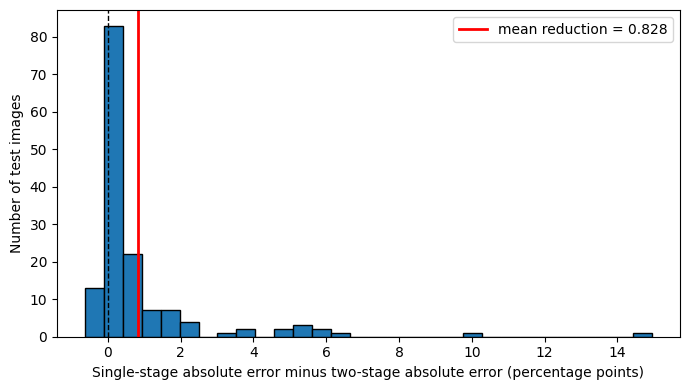

In [10]:
def paired_error_table(a_name, b_name):
    a = pipeline_tables[a_name][["nama_file", "gt", "pred", "abs_error"]].rename(columns={"pred": f"pred_{a_name}", "abs_error": f"abs_error_{a_name}"})
    b = pipeline_tables[b_name][["nama_file", "pred", "abs_error"]].rename(columns={"pred": f"pred_{b_name}", "abs_error": f"abs_error_{b_name}"})
    paired = a.merge(b, on="nama_file", how="inner")
    paired["improvement_abs_error_pct_point"] = paired[f"abs_error_{a_name}"] - paired[f"abs_error_{b_name}"]
    return paired

single_name = "single_stage_single_module"
two_name = "two_stage_single_module_dynamic"
paired = paired_error_table(single_name, two_name)
paired.to_csv(OUT / "severity_paired_errors_single_vs_two_stage.csv", index=False)

diffs = paired["improvement_abs_error_pct_point"].dropna().to_numpy()
rng = np.random.default_rng(RANDOM_SEED)
boot = np.empty(BOOTSTRAP_N)
for i in range(BOOTSTRAP_N):
    boot[i] = rng.choice(diffs, size=len(diffs), replace=True).mean()
ci_low, ci_high = np.percentile(boot, [2.5, 97.5])

wilcoxon = stats.wilcoxon(diffs, alternative="greater", zero_method="wilcox")
sign_test = stats.binomtest(int((diffs > 0).sum()), int((diffs != 0).sum()), p=0.5, alternative="greater")

sig_summary = pd.DataFrame([{
    "comparison": f"{single_name} minus {two_name}",
    "n_paired_images": len(diffs),
    "single_stage_mae_pct": paired[f"abs_error_{single_name}"].mean(),
    "two_stage_mae_pct": paired[f"abs_error_{two_name}"].mean(),
    "mean_mae_reduction_pct_point": diffs.mean(),
    "bootstrap_ci95_low": ci_low,
    "bootstrap_ci95_high": ci_high,
    "wilcoxon_statistic": wilcoxon.statistic,
    "wilcoxon_pvalue_one_sided": wilcoxon.pvalue,
    "n_images_improved": int((diffs > 0).sum()),
    "n_images_worse": int((diffs < 0).sum()),
    "n_images_equal": int((diffs == 0).sum()),
    "sign_test_pvalue_one_sided": sign_test.pvalue,
}])
sig_summary.to_csv(OUT / "severity_mae_significance_single_vs_two_stage.csv", index=False)
display(sig_summary)

plt.figure(figsize=(7, 4))
plt.hist(diffs, bins=30, edgecolor="black")
plt.axvline(diffs.mean(), color="red", linewidth=2, label=f"mean reduction = {diffs.mean():.3f}")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Single-stage absolute error minus two-stage absolute error (percentage points)")
plt.ylabel("Number of test images")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "severity_error_reduction_histogram.png", dpi=300)
plt.show()

## Final Output Index

Jalankan cell ini terakhir untuk melihat semua file output yang dapat dipakai dalam response letter atau revisi manuscript.

In [11]:
outputs = sorted([p for p in OUT.glob("*") if p.is_file()])
for p in outputs:
    print(p.relative_to(ROOT))

reviewer_feedback_outputs\annotated_subset_image_metadata.csv
reviewer_feedback_outputs\fig18_19_caption_recommendations.csv
reviewer_feedback_outputs\fig18_19_yolov12_size_source_audit.csv
reviewer_feedback_outputs\full_dataset_image_metadata.csv
reviewer_feedback_outputs\largest_detected_leaf_assumption_test_model_audit.csv
reviewer_feedback_outputs\largest_detected_leaf_assumption_test_model_summary.csv
reviewer_feedback_outputs\largest_leaf_assumption_per_image_gt.csv
reviewer_feedback_outputs\largest_leaf_assumption_per_leaf_gt.csv
reviewer_feedback_outputs\largest_leaf_assumption_summary_gt.csv
reviewer_feedback_outputs\representativeness_class_balance_chi_square.csv
reviewer_feedback_outputs\representativeness_class_distribution.csv
reviewer_feedback_outputs\representativeness_image_metadata_ks_tests.csv
reviewer_feedback_outputs\severity_error_reduction_histogram.png
reviewer_feedback_outputs\severity_mae_significance_single_vs_two_stage.csv
reviewer_feedback_outputs\severity_p